# XGBoost-malli 1 (paranneltu malli)

XGBoost-mall on gradient boosting -pohjainen puumalli. XGBoost 
soveltuu hyvin epätasapainoisen dataan käsittelyyn ja se pystyy 
mallintamaan myös epälineaarisia yhteyksiä.

Sama aineisto kuin mallissa 1:
- Pitkäaikaissokeri mukana
- Parannettu RandomizedSearchCV:llä — optimoitu 7 hyperparametria
  (puiden määrä, syvyys, oppimisvauhti, näytteistys jne.)
- 50 satunnaista yhdistelmää, 5-kertainen ristiin validointi
- Skaalausta ei tarvita — puumallit eivät ole herkkiä muuttujien mittakaavalle


In [81]:
#!pip install scikit-learn
#!pip install statsmodels
#!pip install shap
#!pip install graphviz


## 1. Kirjastot ja data

In [82]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from xgboost import plot_importance
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm
from xgboost import plot_tree
from matplotlib import rcParams
from sklearn.model_selection import RandomizedSearchCV


In [83]:
df=pd.read_csv("database_original.csv")

In [84]:
df.drop(columns=['HDL', 'Insuliini', 'Kokonaiskolesteroli','BMI', 'Vyotaronymparys','Reipas_liikunta(pv/vk)', 'Kavely(pv/vk)'], inplace=True) 
## poistetaan muuttujat, jotka aiheuttavat multikollineaarisuutta ja iten poistettiin logisten resgression ominaisuuden huomioon ottaen, pois lukien pitkäaikaissokeri

## 2. Datan esikäsittely

Korrelaatiomatriisi ja VIF-analyysi — sama valinta kuin logistisessa regressiossa. XGBoost ei ole herkkä muuttujien skaalalle, joten RobustScaler jätetään pois mallinnuksesta.


In [85]:
corr_matrix =df.corr()

<Axes: >

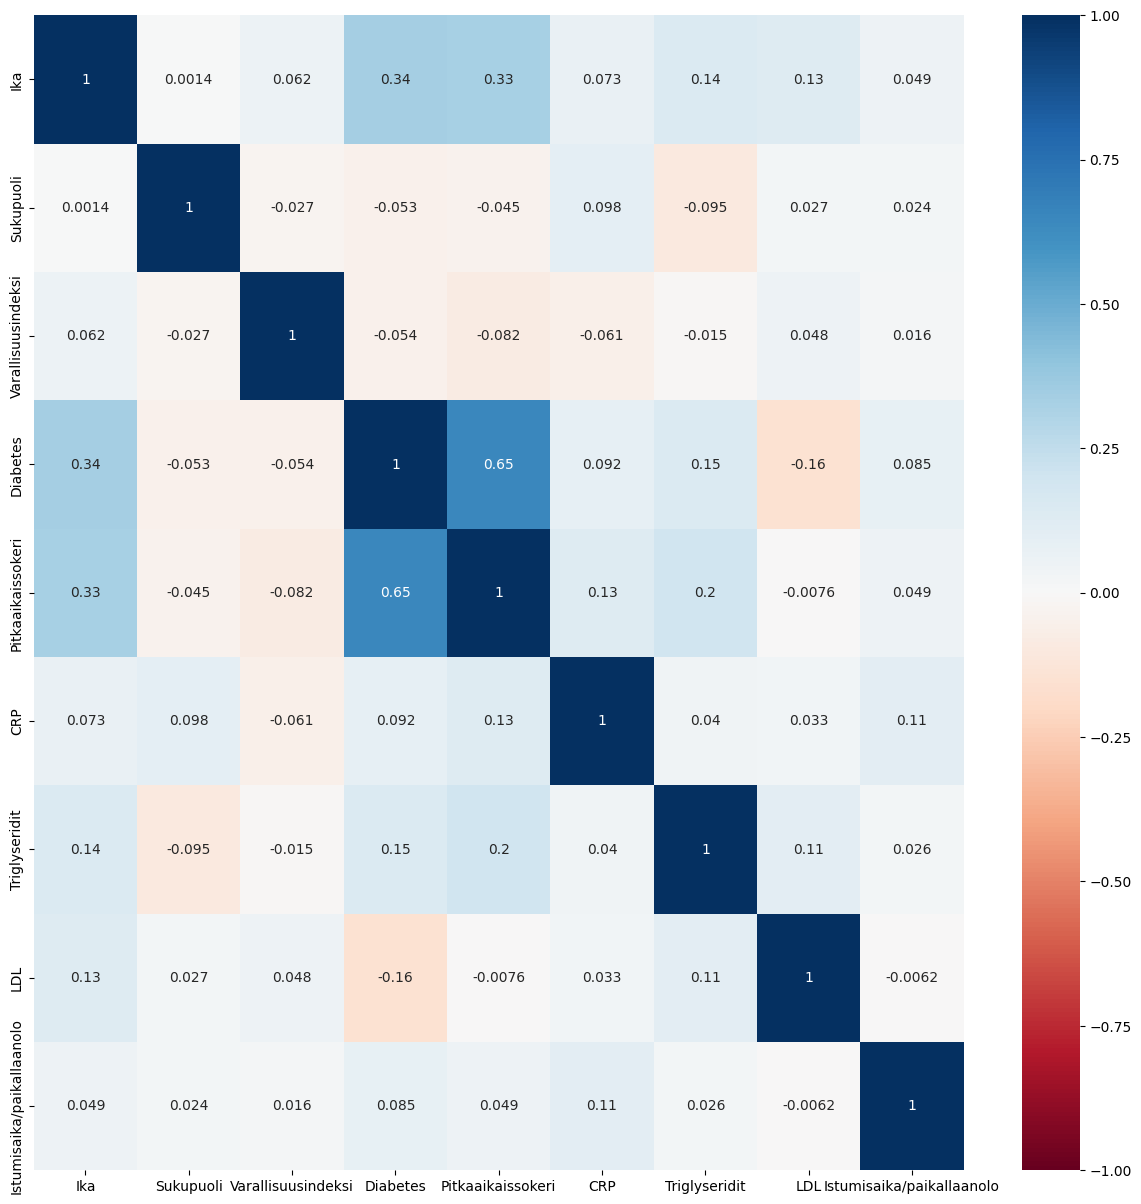

In [86]:
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, vmin = -1.0, vmax = 1.0, cmap ='RdBu', annot = True)

In [87]:
y = df["Diabetes"] #selitettävä muuttuja
X = df.drop("Diabetes", axis=1) #selitettävät muuttujat

vif_df = pd.DataFrame()
vif_df ["Variables"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df

,Variables,VIF
0,Ika,7.021190
1,Sukupuoli,8.370342
2,Varallisuusindeksi,4.988504
3,Pitkaaikaissokeri,17.452024
4,CRP,1.361096
5,Triglyseridit,2.305389
6,LDL,8.765188
7,Istumisaika/paikallaanolo,1.431831


In [88]:
X_train, X_test, y_train, y_test =train_test_split( X, y, test_size=0.2, random_state = 42)

In [89]:
y_train.value_counts().round(2)

Diabetes
0    2115
1     357
Name: count, dtype: int64

In [90]:
y_test.value_counts().round(2)

Diabetes
0    538
1     80
Name: count, dtype: int64



Aineistossa on luokkaimbalanssi: 86% ei-diabeetikkoja ja 14% 
diabeetikkoja. Tämä on huomioitu scale_pos_weight-parametrilla.

## 3. Mallin rakentaminen

Rakennetaan paranneltu XGBoost-malli diabeteksen tunnistamiseksi.

Mallia ei tarvitse skaalata kuten logistisessa regressiossa, 
koska puupohjaiset menetelmät eivät ole herkkiä muuttujien 
mittakaavalle.

Luokkaimbalanssi (86%/14%) korjataan scale_pos_weight-parametrilla,
joka on XGBoostin vastaava mekanismi logistisen regression 
class_weight='balanced':lle:

scale_pos_weight = enemmistöluokan määrä / vähemmistöluokan määrä
= 2115 / 357 ≈ 5.9

Perusmalliin verrattuna paranneltu malli:
- Optimoi 7 hyperparametria automaattisesti RandomizedSearchCV:llä
- 50 satunnaista yhdistelmää 9 216 mahdollisesta
- 5-kertainen ristiin validointi ylisovittamisen estämiseksi
- Optimoitu AUC:n mukaan

RandomizedSearchCV valitsi parhaaksi yhdistelmäksi:
- n_estimators: 100 — riittävä puiden määrä tällä aineistolla
- max_depth: 4 — maltillinen syvyys estää ylisovittamista
- learning_rate: 0.01 — hidas oppiminen parantaa yleistymistä
- subsample: 0.7 — osittainen näytteistys vähentää varianssia
- colsample_bytree: 0.8 — käyttää 80% muuttujista per puu



In [91]:
scale = 2115 / 357
param_grid = {
   "n_estimators": [100, 200, 300, 500],
   "max_depth": [3, 4, 5, 6],
   "learning_rate": [0.01, 0.03, 0.05, 0.1],
   "subsample": [0.7, 0.8, 0.9, 1.0],
   "colsample_bytree": [0.6, 0.8, 1.0],
   "min_child_weight": [1, 3, 5],
   "gamma": [0, 0.1, 0.3, 1]
}

xgb = XGBClassifier(scale_pos_weight=scale, random_state=42)

search = RandomizedSearchCV(
   xgb, param_grid,
   n_iter=50,
   scoring='roc_auc',
   cv=5,
   random_state=42,
   n_jobs=-1
)

search.fit(X_train, y_train)
print("Parhaat parametrit:", search.best_params_)
xgb_best = search.best_estimator_

Parhaat parametrit: {'subsample': 0.7, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}


XGBoost-malli koulutettiin käyttäen scale_pos_weight‑parametria (≈ 5.9) korjaamaan luokkien epätasapaino (86 % / 14 %). Tämä vastaa logistisen regression class_weight balanced ‑asetusta ja lisää vähemmistöluokan painoa mallin oppimisessa. Malli rakennettiin 100 puulla (n_estimators=100), pienellä oppimisnopeudella (0.01) ja osittaisella näytteenotolla 
(subsample=0.7, colsample_bytree=0.8) ylisovituksen estämiseksi.

## 4. Mallin arviointi

### 4.1 Ennustetut todennäköisyydet ja jakauma

In [92]:
Y_pred = xgb_best.predict(X_test) #luokkien ennusteet eli 0= "ei diabetestä" ja 1= "diabetes" -> tarvitaan confusion matrixissa ja accuracyssa
Y_pred_probabilities = xgb_best.predict_proba(X_test)[:,1] #luokkien todennäköisyydet -> AUC, ROC, riskimallit
Y_pred_probabilities

array([0.24177302, 0.7035312 , 0.2571508 , 0.3737612 , 0.20643578,
       0.18764085, 0.22231942, 0.2084351 , 0.23222242, 0.77818567,
       0.2255171 , 0.18587138, 0.21165138, 0.309781  , 0.18696602,
       0.25646198, 0.43776715, 0.72885615, 0.18738134, 0.40907726,
       0.20961738, 0.3266955 , 0.76262814, 0.19556093, 0.20986484,
       0.2502129 , 0.23390427, 0.7981186 , 0.47015527, 0.26062432,
       0.19176881, 0.22985566, 0.309128  , 0.19522008, 0.19485588,
       0.20931683, 0.19687197, 0.2839012 , 0.5305732 , 0.19455585,
       0.2365515 , 0.19693314, 0.24818681, 0.20923497, 0.19455585,
       0.72069216, 0.25130558, 0.18708554, 0.6367265 , 0.2566009 ,
       0.4523493 , 0.24465822, 0.7939147 , 0.2893263 , 0.3843191 ,
       0.5339393 , 0.8000493 , 0.51132154, 0.27272844, 0.7772309 ,
       0.19625844, 0.1914957 , 0.2069824 , 0.26697487, 0.52427316,
       0.237924  , 0.21649581, 0.22881618, 0.25681686, 0.33828413,
       0.36108375, 0.27214938, 0.20771463, 0.19274308, 0.23953

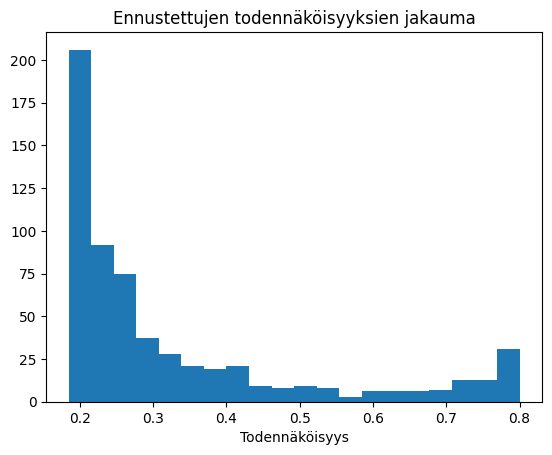

In [93]:
plt.hist(Y_pred_probabilities, bins=20)
plt.xlabel('Todennäköisyys')
plt.title('Ennustettujen todennäköisyyksien jakauma')
plt.show()



Histogrammi näyttää mallin antamien todennäköisyysennusteiden 
jakauman. Suurin piikki on lähellä nollaa — suurimmalle osalle 
testijoukon henkilöistä malli ennustaa matalaa diabetesriskiä, 
mikä vastaa aineiston luokkajakaumaa (86% ei-diabeetikkoja).

Jakauma on selvästi kaksihuippuinen — suuri piikki lähellä 
nollaa ja toinen lähellä ykköstä. Tämä kertoo että malli on 
varma ennusteissaan: se luokittelee henkilöt joko selvästi 
ei-diabeetikoiksi tai selvästi diabeetikoiksi, harvoin 
epävarmasti keskialueelle. Tämä ei kuitenkaan yksin kerro vielä mallin hyvyydestä, 
vaan jakaumaa pitää tulkita yhdessä ROC:n, recallin ja confusion matrixin kanssa.

### 4.2 Log Loss
Mittaa kuinka tarkasti ja varmasti malli antaa todennäköisyyksiä.
Mitä lähempänä 0 sitä parempi:
- alle 0.3 → erinomainen
- 0.3–0.5 → hyvä
- yli 0.7 → heikko


In [94]:
logloss = log_loss(y_test, Y_pred_probabilities)
print(logloss)

0.356453807765803


Log Loss = 0.356 — hyvä tulos (0.3–0.5). Tämä viittaa siihen, 
että mallin todennäköisyysennusteet ovat kohtuullisen tarkkoja.

### 4.3 AUC ja ROC-käyrä
ROC-käyrä kuvaa mallin erottelukykyä eri kynnysarvoilla.
AUC mittaa mallin kykyä erotella diabeetikot ei-diabeetikoista 
eri päätöskynnysarvoilla. Arvo 1.0 on täydellinen ja 0.5 
vastaa satunnaista arvausta.

- 0.9–1.0 → erinomainen
- 0.8–0.9 → hyvä  
- 0.7–0.8 → kohtalainen

In [95]:
auc = roc_auc_score(y_test, Y_pred_probabilities)
print("AUC", auc)

AUC 0.9507086431226766


AUC = 0.951 — erinomainen. Malli erottelee diabeteksen 
ei-diabeteksestä erittäin hyvin.



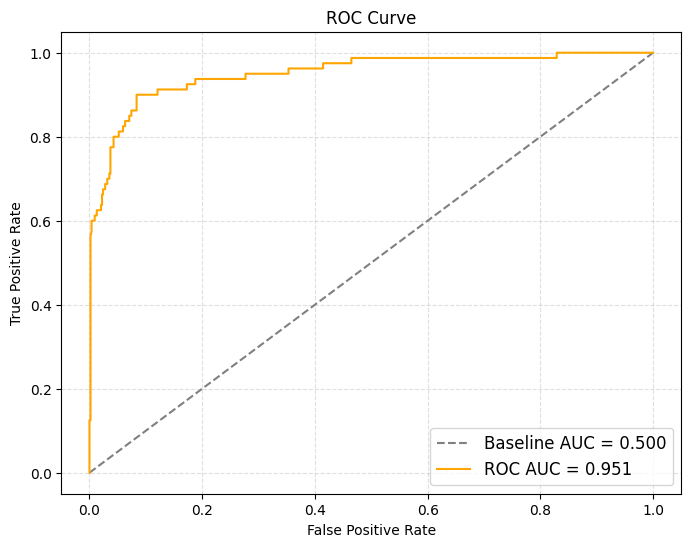

In [96]:
baseline_probs = [0 for _ in range(len(y_test))] # baseline-malli

Y_pred_probabilities = xgb_best.predict_proba(X_test)[:, 1] # mallin todennäköisyydet luokalle 1


baseline_auc = roc_auc_score(y_test, baseline_probs) # baseline AUC
pc_auc = roc_auc_score(y_test, Y_pred_probabilities) #predict_probalities AUC

# ROC-käyrän pisteet
baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_probs)
fpr, tpr, thresholds = roc_curve(y_test, Y_pred_probabilities, drop_intermediate=False)

# ROC-käyrä
plt.figure(figsize=(8,6))

plt.plot(
    baseline_fpr, baseline_tpr,
    linestyle='--', color='gray',
    label=f'Baseline AUC = {baseline_auc:.3f}'
)

plt.plot(
    fpr, tpr,
    color='orange',
    label=f'ROC AUC = {pc_auc:.3f}'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

ROC-käyrä nousee jyrkästi vasempaan yläkulmaan, mikä kertoo hyvästä 
herkkyydestä pienellä väärän positiivisen määrällä.

### 4.4 Confusion Matrix ja Classification Report

Binääriset ennusteet arvioidaan confusion matrixin avulla.
Kliinisessä kontekstissa recall on tärkein mittari — 
väärä negatiivinen (diabeetikko jää tunnistamatta) on 
haitallisempi kuin väärä positiivinen.

In [97]:
cm = confusion_matrix(y_test, Y_pred)
print("Confusion matrix:\n",cm)
accuracy = accuracy_score(y_test, Y_pred)
print("\nAccuracy = %.3f" % (accuracy)) 
print("\nClassification report\n")
print(classification_report(y_test, Y_pred))

Confusion matrix:
 [[504  34]
 [ 13  67]]

Accuracy = 0.924

Classification report

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       538
           1       0.66      0.84      0.74        80

    accuracy                           0.92       618
   macro avg       0.82      0.89      0.85       618
weighted avg       0.93      0.92      0.93       618



Malli tunnistaa 84% diabeetikoista oikein (recall=0.84) ja 
94% ei-diabeetikoista oikein. Vääriä negatiivisia on 13 — 
eli 13 diabeetikkoa jäi tunnistamatta. Vääriä positiivisia 
on 34 — eli 34 tervettä luokiteltiin virheellisesti 
diabeetikoiksi. Kokonaistarkkuus 0.924 on korkea.

### 4.5 Feature Importance

Gain-tyyppinen tärkeys kertoo kuinka paljon kukin muuttuja 
parantaa mallin ennustekykyä päätöspuun haarautumiskohdissa 
keskimäärin. Mitä suurempi gain, sitä tärkeämpi muuttuja 
on mallille.

In [98]:

importances = pd.Series(xgb_best.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False))



Pitkaaikaissokeri            0.644126
Ika                          0.115875
LDL                          0.074748
Triglyseridit                0.045161
Sukupuoli                    0.034733
CRP                          0.032632
Varallisuusindeksi           0.030357
Istumisaika/paikallaanolo    0.022368
dtype: float32


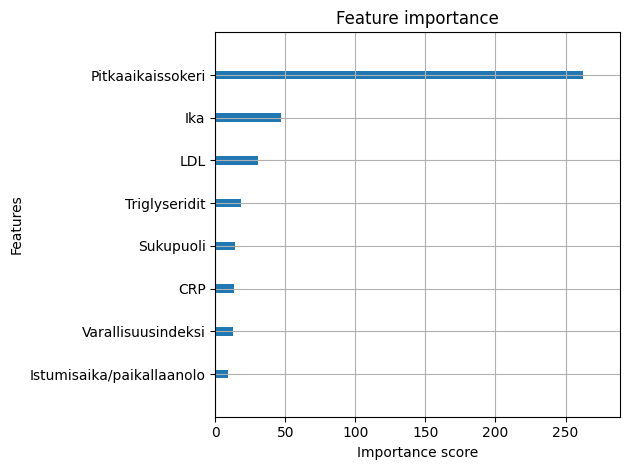

In [99]:
plot_importance(xgb_best, importance_type='gain',  max_num_features=8,show_values=False)
plt.tight_layout()
plt.show()

Pitkäaikaissokeri dominoi selvästi mallia — sen gain-arvo 
(0.64) on yli 5-kertainen seuraavaan muuttujaan (ikä, 0.12) 
verrattuna. Pitkäaikaissokeri on ylivoimaisesti merkitsevin 
yksittäinen diabeteksen ennustaja mallissa.

Ikä ja LDL ovat seuraavaksi tärkeimmät. Muut muuttujat 
— triglyseridit, CRP, sukupuoli, varallisuusindeksi ja 
istumisaika — jakavat lopun tärkeyden tasaisemmin 

### 4.6 SHAP-analyysi

SHAP (SHapley Additive exPlanations) selittää yksittäisten 
muuttujien vaikutuksen mallin päätöksiin sekä suunnan että 
voimakkuuden osalta. Toisin kuin feature importance, SHAP 
kertoo myös lisääkö vai vähentääkö muuttujan arvo 
diabetesriskiä.

tulkinta:

SHAP-kuvassa punaiset pisteet kuvaavat korkeita muuttuja-arvoja ja siniset matalia. 
Oikealle siirtyvät arvot kasvattavat diabeteksen ennustettua todennäköisyyttä ja vasemmalle siirtyvät pienentävät sitä.



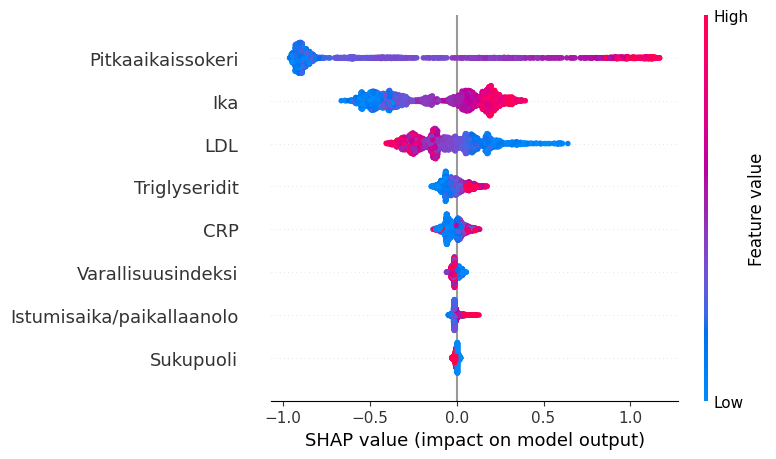

In [102]:
explainer = shap.TreeExplainer(xgb_best) #Mitkä muutujat vaikuttavat mallin päätöksiin ja miten.
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)




SHAP-arvot vahvistavat feature importancen tulokset ja kertovat 
lisäksi vaikutuksen suunnan:

-Pitkäaikaissokeri: Selvästi tärkein muuttuja. Korkea arvo 
(punainen) työntää ennustetta voimakkaasti kohti diabetesta, 
matala arvo (sininen) poispäin. Hajonta on suurin kaikista 
muuttujista.

-Ikä: Korkea ikä lisää diabetesriskiä, matala ikä vähentää 
— selkeä ja looginen yhteys.

-LDL: Mielenkiintoinen käänteinen kuvio — korkea LDL 
(punainen) näyttää vähentävän riskiä ja matala LDL lisäävän. 
Tämä on biologisesti yllättävä (voi heijastaa 
kolesterolilääkityksen vaikutusta aineistossa.)

-Varallisuusindeksi: SHAP-arvot keskittyvät lähelle nollaa 
— vaikutus on pieni mutta havaittavissa.

-CRP ja triglyseridit: Kohonneet arvot lisäävät riskiä 
lievästi — linjassa tulehduksen ja metabolisen oireyhtymän 
kanssa.

Sukupuoli: SHAP-arvot keskittyvät lähes nollaan — 
vahvistaa että sukupuolella ei ole merkittävää vaikutusta 
tässä mallissa.


### 4.7 Päätöspuuvisualisointi

XGBoostin yksittäiset päätöspuut visualisoidaan havainnollistamaan 
mallin päätöksentekoprosessia. äätöspuu havainnollistaa yhden yksittäisen boosting-vaiheen rakennetta, 
mutta sitä ei tule tulkita koko mallin päätöksentekona. XGBoostin ennuste muodostuu kaikkien puiden yhteisvaikutuksesta.

In [103]:
rcParams['figure.dpi'] = 400
fig, ax = plt.subplots(figsize=(80, 50))
plot_tree(xgb_best, tree_idx=6, ax=ax)
plt.show()

Tässä puussa ensimmäinen jako tehdään pitkäaikaissokerin 
perusteella (< 0.99) — vahvistaa sen dominoivan roolin mallissa. 
Seuraavilla tasoilla käytetään ikää, LDL:ää ja triglyseriditä 
tarkentamaan ennustetta. 
